# Model Training — Feature Selection & Optimal Model

**Goal:** Find the optimal feature set for predicting 5-min BTC candle outcomes.

**Data:** `data/latest_features.jsonl` (generated by notebook 6 from collection.db, 60 indicators including volume).

**Approach:**
1. Load pre-computed features
2. Time-based train/test split (candle-level, no leakage)
3. Baseline: LinearRegression with all 60 features
4. Individual feature ranking
5. Forward selection: find optimal N
6. LogisticRegression comparison
7. Final recommendation

In [1]:
import json
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from evaluator import Evaluator
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm

random.seed(42)
np.random.seed(42)

## 1. Load data

**What:** Load the feature-engineered JSONL into a pandas DataFrame.

**Why:** Pandas gives us easy column selection, null handling, and direct integration with scikit-learn. Each row is one snapshot with 47 indicator columns and the `outcome` label.

**Result:** A DataFrame with ~94K rows. The print shows shape and column count.

In [2]:
DATA_PATH = Path("../data/latest_features.jsonl")

rows = []
with open(DATA_PATH) as f:
    for line in f:
        rows.append(json.loads(line))

df = pd.DataFrame(rows)
print(f"Loaded {len(df):,} rows, {df['candle_id'].nunique()} candles, {len(df.columns)} columns")

Loaded 53,377 rows, 1103 candles, 76 columns


## 2. Preprocessing

Encode target, identify feature columns (60 indicators), fill NaN with 0.0, normalize with StandardScaler.

In [3]:
# Encode target
df["target"] = (df["outcome"] == "UP").astype(int)

# Identify feature columns (exclude IDs, raw snapshot fields, target)
NON_FEATURE_COLS = {
    "candle_id",
    "session",
    "timestamp",
    "elapsed_pct",
    "btc_price",
    "up_best_bid",
    "up_best_ask",
    "up_bid_depth",
    "up_ask_depth",
    "down_best_bid",
    "down_best_ask",
    "down_bid_depth",
    "down_ask_depth",
    "market_volume",
    "outcome",
    "target",
}
feature_cols = [c for c in df.columns if c not in NON_FEATURE_COLS]
print(f"Feature columns ({len(feature_cols)}): {feature_cols}")

# Handle nulls
null_counts = df[feature_cols].isnull().sum()
print("\nNull counts per feature (top 10):")
print(null_counts.sort_values(ascending=False).head(10))

df[feature_cols] = df[feature_cols].fillna(0.0)

# Normalize
scaler = StandardScaler()
X = scaler.fit_transform(df[feature_cols])
y = df["target"].values

print(f"\nX shape: {X.shape}")
print(
    f"y distribution: UP={y.sum():,} ({y.mean() * 100:.1f}%), DOWN={(1 - y).sum():,.0f} ({(1 - y.mean()) * 100:.1f}%)"
)

Feature columns (60): ['prior_return', 'consecutive_streak', 'streak_magnitude', 'rolling_volatility', 'candle_momentum', 'ma_crossover', 'trend_consistency', 'reversal_regime', 'rsi', 'bollinger_pct_b', 'stochastic_k', 'adx', 'return_autocorrelation', 'multi_candle_return_3', 'multi_candle_return_6', 'btc_move_from_open', 'btc_velocity', 'intra_candle_volatility', 'peak_drawback', 'btc_acceleration', 'btc_direction_consistency', 'intra_candle_skewness', 'intra_candle_kurtosis', 'hurst_exponent', 'market_efficiency_lag', 'up_implied_probability', 'up_book_imbalance', 'cross_book_flow', 'up_spread_level', 'token_price_divergence', 'up_risk_reward', 'up_token_velocity', 'down_implied_probability', 'down_book_imbalance', 'down_token_velocity', 'down_risk_reward', 'rr_spread', 'weighted_mid_price', 'btc_token_correlation', 'liquidity_decay', 'imbalance_momentum', 'spread_compression', 'observation_window', 'current_elapsed', 'time_of_day_sin', 'time_of_day_cos', 'imbalance_shift', 'smart_m

## 3. Train / Test Split (time-based, candle-level)

Split by time: first 80% of candles for training, last 20% for testing. No candle appears in both.

In [4]:
# Time-based split (no leakage)
candle_ids = df["candle_id"].unique()
split_idx = int(len(candle_ids) * 0.8)
train_ids = set(candle_ids[:split_idx])
test_ids = set(candle_ids[split_idx:])

train_mask = df["candle_id"].isin(train_ids)
test_mask = df["candle_id"].isin(test_ids)

X_train, X_test = X[train_mask], X[test_mask]
y_train, y_test = y[train_mask], y[test_mask]

print(f"Train: {X_train.shape[0]:,} samples from {len(train_ids)} candles")
print(f"Test:  {X_test.shape[0]:,} samples from {len(test_ids)} candles")
print(f"UP rate: train={y_train.mean() * 100:.1f}% test={y_test.mean() * 100:.1f}%")

Train: 42,925 samples from 882 candles
Test:  10,452 samples from 221 candles
UP rate: train=52.9% test=47.0%


## 4. Baseline — LinearRegression with ALL features

**What:** Train a LinearRegression model using all 47 features and evaluate it on the test set.

**Why:** This is our baseline — the best the model can do with all available information. We'll compare all subsequent experiments against this. If individual features or subsets perform *better*, it means some features are adding noise rather than signal.

**How it works:**
- LinearRegression minimizes the sum of squared errors between predictions and true labels (0 or 1)
- The output is a continuous value (predicted probability of UP). Values > 0.5 → predict UP, ≤ 0.5 → predict DOWN
- We clip predictions to [0, 1] since LinearRegression can produce values outside this range

**How to read the charts:**
- **Left (Predictions scatter):** Each dot is a test sample. Y-axis = predicted probability. Green = correct prediction, red = incorrect. The gray dashed line at 0.5 is the decision boundary. Good models have green dots clustered near 0 and 1, with few red dots.
- **Middle (Error distribution):** Histogram of (predicted - actual). Centered at 0 = unbiased. Wide spread = high error. The orange line shows mean error — positive means the model over-predicts UP.
- **Right (Confusion matrix):** 2x2 grid. Top-left = true DOWN predicted DOWN (correct). Bottom-right = true UP predicted UP (correct). Off-diagonal = errors. Higher diagonal values = better model.

=== All Features (47) ===
  Regression:      MSE=0.1610  R²=35.4%  MAE=0.3255
  Classification:  Accuracy=76.3%  Precision=75.1%  Recall=74.3%  F1=74.7%
  Samples:         10452 (UP=4911, DOWN=5541)


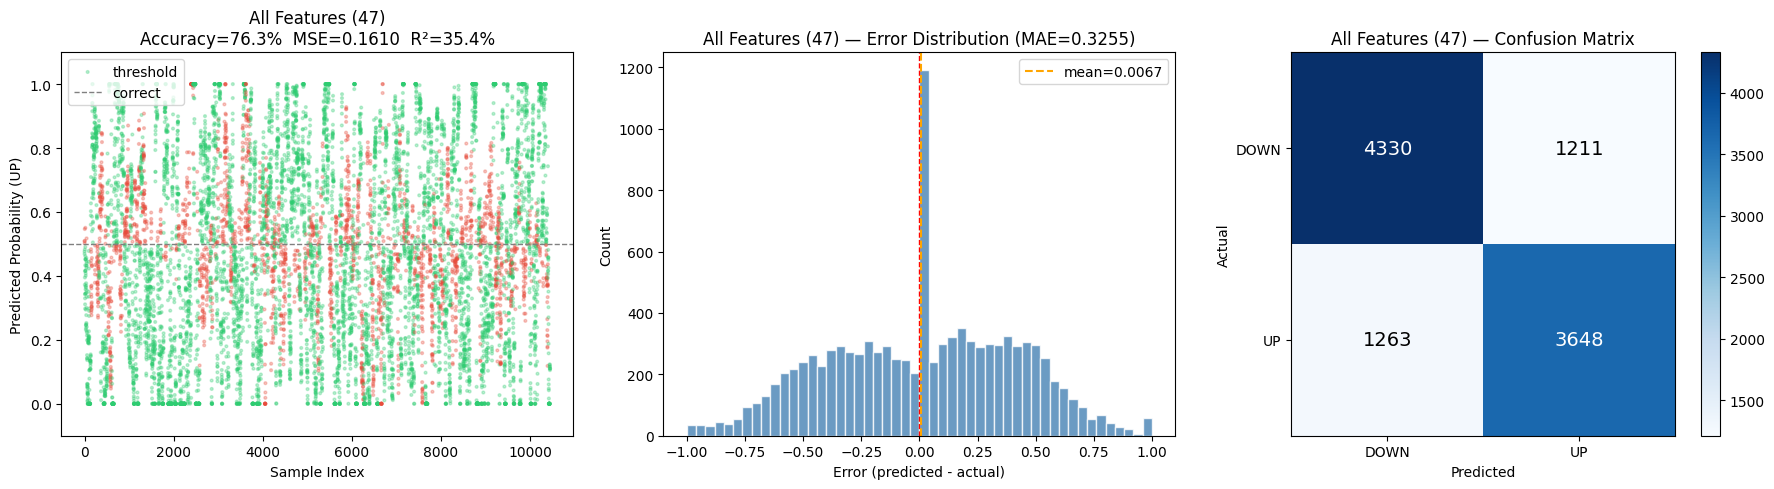

In [5]:
# Train
model_all = LinearRegression()
model_all.fit(X_train, y_train)

# Predict
y_prob_all = np.clip(model_all.predict(X_test), 0, 1)
y_pred_all = (y_prob_all >= 0.5).astype(int)

# Evaluate
ev_all = Evaluator(y_test, y_pred_all, y_prob_all, title="All Features (47)")
ev_all.full_report()

## 5. Individual Feature Ranking

**What:** Train 47 separate models, each using only ONE feature, and rank them by accuracy.

**Why:** This reveals which individual features carry the most predictive signal on their own. Some features may have high effect size (mean separation) but low classification power, or vice versa. Training an actual model captures non-linear thresholding effects that raw mean comparison misses.

**How it works:** For each feature:
1. Extract just that one column from X_train and X_test
2. Train a LinearRegression
3. Predict on test set, compute accuracy
4. Store results, sort by accuracy descending

**How to read the bar chart:**
- Each bar = one feature, sorted from best to worst accuracy
- **Red dashed line at 50%** = random baseline (coin flip). Any feature below this line is worse than guessing.
- **Green bars** = accuracy > 52% (meaningfully better than random)
- **Orange bars** = 50-52% (marginal)
- **Gray bars** = below 50% (anti-predictive — these features might actually be useful if you flip their sign)
- Features at the top are the strongest individual predictors.

In [6]:
individual_results = []

for i, col in enumerate(tqdm(feature_cols, desc="Individual features")):
    Xi_train = X_train[:, i].reshape(-1, 1)
    Xi_test = X_test[:, i].reshape(-1, 1)

    m = LinearRegression()
    m.fit(Xi_train, y_train)

    prob = np.clip(m.predict(Xi_test), 0, 1)
    pred = (prob >= 0.5).astype(int)
    acc = float(np.mean(pred == y_test))
    mse = float(np.mean((prob - y_test) ** 2))

    individual_results.append((col, acc, mse))

individual_results.sort(key=lambda x: -x[1])

print(f"{'Feature':<35} {'Accuracy':>8} {'MSE':>8}")
print("-" * 55)
for name, acc, mse in individual_results:
    print(f"{name:<35} {acc * 100:>7.2f}% {mse:>8.4f}")

Individual features: 100%|██████████| 60/60 [00:00<00:00, 881.71it/s]

Feature                             Accuracy      MSE
-------------------------------------------------------
btc_move_from_open                    75.49%   0.1715
up_implied_probability                73.07%   0.1847
down_implied_probability              71.83%   0.1946
conviction_score                      71.58%   0.1981
up_token_velocity                     70.94%   0.1928
down_token_velocity                   70.93%   0.1928
btc_velocity                          69.35%   0.2104
up_spread_level                       66.87%   0.2059
rr_spread                             59.65%   0.2279
intra_candle_skewness                 59.24%   0.2335
up_risk_reward                        55.31%   0.2395
btc_acceleration                      50.82%   0.2498
multi_candle_return_6                 49.75%   0.2593
stochastic_k                          49.28%   0.2542
bollinger_pct_b                       48.83%   0.2541
candle_momentum                       48.80%   0.2556
volume_momentum           

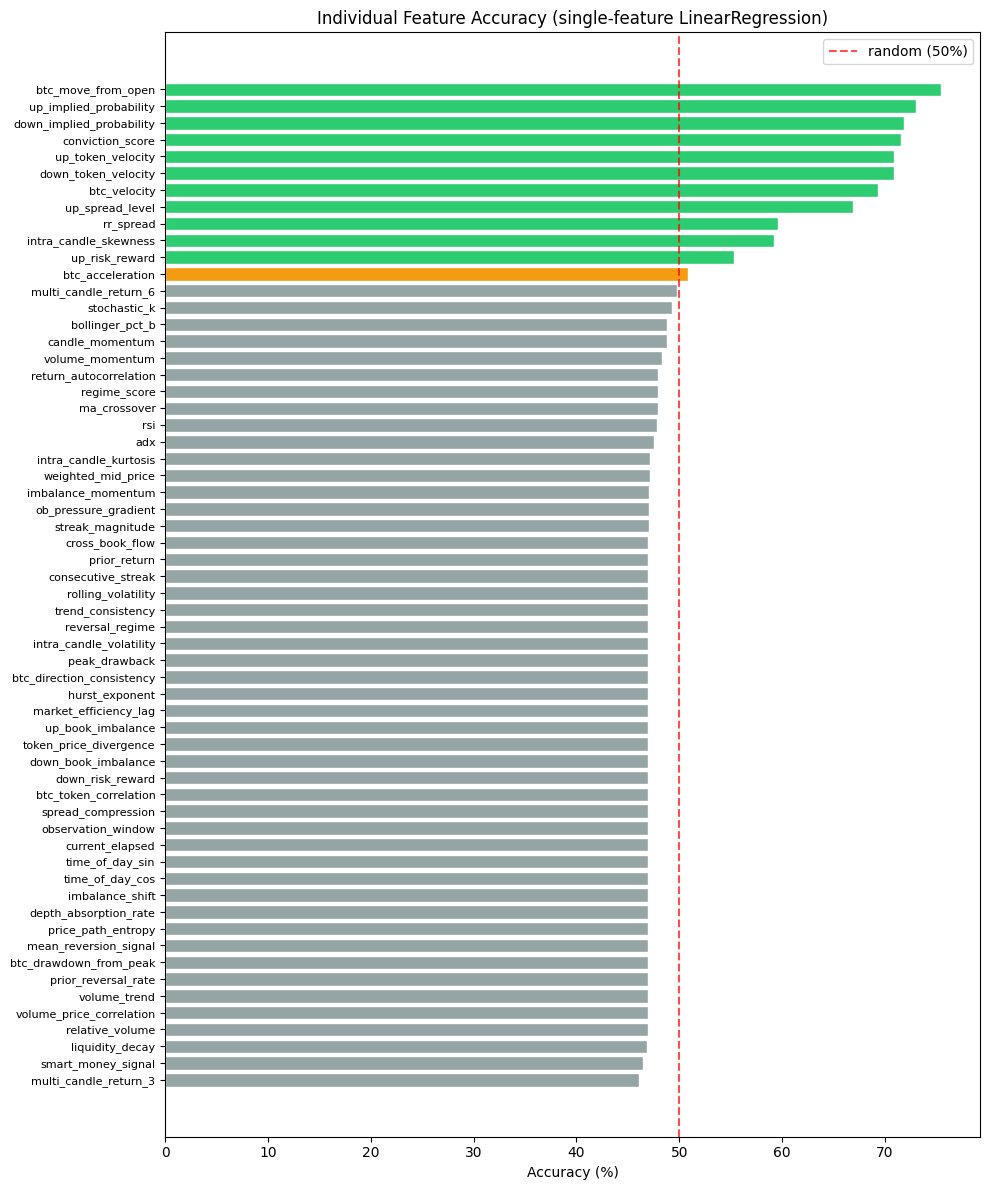

In [7]:
# Bar chart of individual feature accuracy
names = [r[0] for r in individual_results]
accs = [r[1] * 100 for r in individual_results]

fig, ax = plt.subplots(figsize=(10, 12))
colors = ["#2ecc71" if a > 52 else "#f39c12" if a > 50 else "#95a5a6" for a in accs]
ax.barh(range(len(names)), accs, color=colors, edgecolor="white")
ax.set_yticks(range(len(names)))
ax.set_yticklabels(names, fontsize=8)
ax.set_xlabel("Accuracy (%)")
ax.set_title("Individual Feature Accuracy (single-feature LinearRegression)")
ax.axvline(50, color="red", linestyle="--", alpha=0.7, label="random (50%)")
ax.invert_yaxis()
ax.legend()
plt.tight_layout()
plt.show()

## 6. Forward Feature Selection — Find Optimal N

**What:** Starting from an empty set, greedily add one feature at a time — always picking the feature that gives the biggest accuracy improvement. Run through ALL features, then automatically find the peak accuracy point. Features added after the peak are noise that causes overfitting.

**Why:** Instead of picking an arbitrary top-10, we let the data tell us the optimal feature count. The accuracy curve typically:
1. **Rises quickly** as the first few strong features are added
2. **Plateaus** when most learnable signal is captured
3. **Drops** when noisy features are added, causing overfitting

The peak of this curve is the optimal N — the point where we have maximum signal and minimum noise.

**How it works:**
1. Forward-select through all 47 features, tracking accuracy at each step
2. Find the step with highest accuracy = `N_best`
3. Everything after `N_best` is cut — those features hurt more than they help

**How to read the output:**
- The line chart shows accuracy vs number of features
- **Green dot** = the peak (optimal N)
- **Red shaded region** = features beyond the peak (overfitting zone)
- The steeper the initial climb, the more predictive the top features are
- A sharp drop after the peak means those features are actively harmful

In [8]:
N_TOTAL = len(feature_cols)
selected_indices = []
selected_names = []
remaining = list(range(N_TOTAL))
history = []  # (n_features, accuracy, feature_added)

for step in tqdm(range(N_TOTAL), desc="Forward selection"):
    best_acc = -1
    best_idx = -1

    for candidate in remaining:
        trial = selected_indices + [candidate]
        Xi_train = X_train[:, trial]
        Xi_test = X_test[:, trial]

        m = LinearRegression()
        m.fit(Xi_train, y_train)
        prob = np.clip(m.predict(Xi_test), 0, 1)
        pred = (prob >= 0.5).astype(int)
        acc = float(np.mean(pred == y_test))

        if acc > best_acc:
            best_acc = acc
            best_idx = candidate

    selected_indices.append(best_idx)
    selected_names.append(feature_cols[best_idx])
    remaining.remove(best_idx)
    history.append((step + 1, best_acc, feature_cols[best_idx]))

    if (step + 1) % 10 == 0 or step < 5:
        print(f"  Step {step + 1:>2}: +{feature_cols[best_idx]:<30} → accuracy={best_acc * 100:.2f}%")

# Find optimal N = peak accuracy
accs_arr = [h[1] for h in history]
N_best = int(np.argmax(accs_arr)) + 1
best_acc_val = max(accs_arr)

print(f"\n{'=' * 60}")
print(f"Optimal N = {N_best} features (accuracy = {best_acc_val * 100:.2f}%)")
print(f"All {N_TOTAL} features accuracy = {accs_arr[-1] * 100:.2f}%")
print(f"Overfitting cost = {(best_acc_val - accs_arr[-1]) * 100:+.2f}% from extra features")
print(f"{'=' * 60}")

# The optimal feature set
optimal_indices = selected_indices[:N_best]
optimal_names = selected_names[:N_best]
print(f"\nOptimal features: {optimal_names}")

Forward selection:   3%|▎         | 2/60 [00:00<00:04, 13.35it/s]

  Step  1: +btc_move_from_open             → accuracy=75.49%
  Step  2: +up_spread_level                → accuracy=76.31%


Forward selection:   7%|▋         | 4/60 [00:00<00:06,  8.26it/s]

  Step  3: +ob_pressure_gradient           → accuracy=76.44%
  Step  4: +rr_spread                      → accuracy=76.52%


Forward selection:  10%|█         | 6/60 [00:00<00:08,  6.61it/s]

...

  Step 40: +hurst_exponent                 → accuracy=77.84%


Forward selection:  83%|████████▎ | 50/60 [00:16<00:03,  3.24it/s]

  Step 50: +streak_magnitude               → accuracy=76.87%


Forward selection: 100%|██████████| 60/60 [00:17<00:00,  3.36it/s]

  Step 60: +peak_drawback                  → accuracy=76.33%

Optimal N = 35 features (accuracy = 78.11%)
All 60 features accuracy = 76.33%
Overfitting cost = +1.78% from extra features

Optimal features: ['btc_move_from_open', 'up_spread_level', 'ob_pressure_gradient', 'rr_spread', 'volume_momentum', 'relative_volume', 'btc_direction_consistency', 'down_risk_reward', 'depth_absorption_rate', 'weighted_mid_price', 'spread_compression', 'imbalance_momentum', 'imbalance_shift', 'mean_reversion_signal', 'rsi', 'reversal_regime', 'intra_candle_kurtosis', 'prior_reversal_rate', 'token_price_divergence', 'up_book_imbalance', 'down_book_imbalance', 'cross_book_flow', 'smart_money_signal', 'btc_velocity', 'up_risk_reward', 'time_of_day_sin', 'market_efficiency_lag', 'bollinger_pct_b', 'intra_candle_volatility', 'trend_consistency', 'liquidity_decay', 'volume_price_correlation', 'volume_trend', 'time_of_day_cos', 'consecutive_streak']


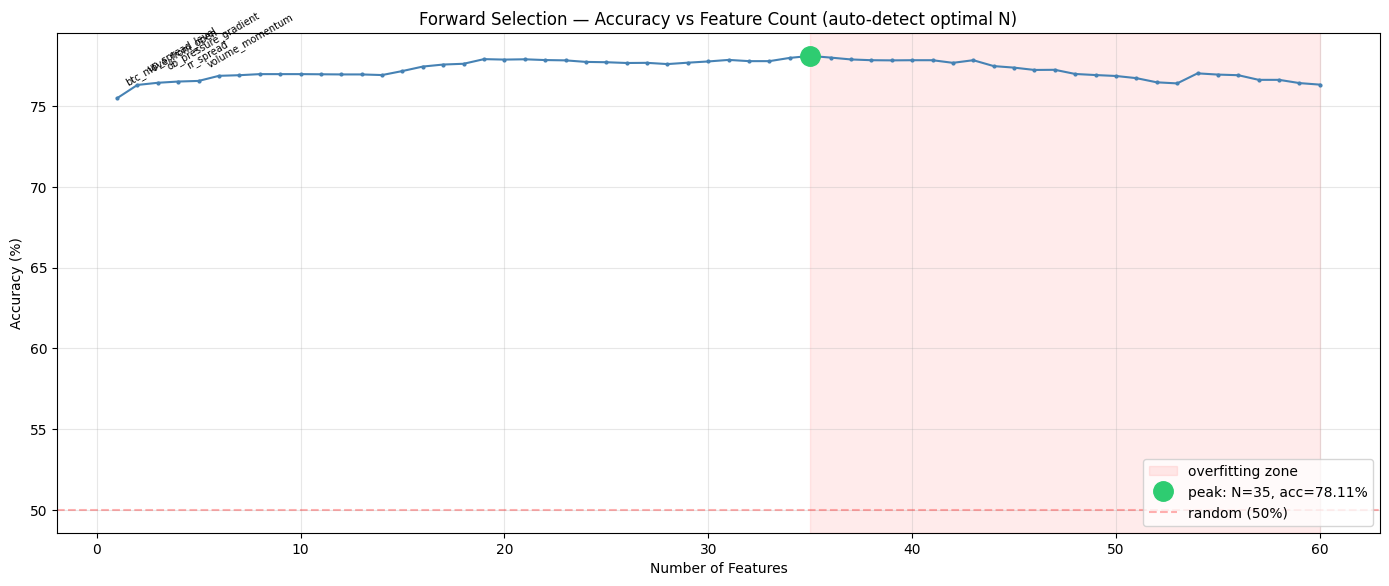

In [9]:
# Accuracy vs number of features — with peak and overfitting zone
steps = [h[0] for h in history]
step_accs = [h[1] * 100 for h in history]

fig, ax = plt.subplots(figsize=(14, 6))

# Overfitting zone (shaded red after peak)
ax.axvspan(N_best, N_TOTAL, alpha=0.08, color="red", label="overfitting zone")

# Accuracy curve
ax.plot(steps, step_accs, marker=".", color="steelblue", linewidth=1.5, markersize=4)

# Peak marker
ax.plot(
    N_best,
    best_acc_val * 100,
    "o",
    color="#2ecc71",
    markersize=14,
    zorder=5,
    label=f"peak: N={N_best}, acc={best_acc_val * 100:.2f}%",
)

# Annotate the first few features
for i in range(min(5, N_best)):
    ax.annotate(
        history[i][2], (steps[i], step_accs[i]), textcoords="offset points", xytext=(5, 10), fontsize=7, rotation=30
    )

ax.set_xlabel("Number of Features")
ax.set_ylabel("Accuracy (%)")
ax.set_title("Forward Selection — Accuracy vs Feature Count (auto-detect optimal N)")
ax.axhline(50, color="red", linestyle="--", alpha=0.3, label="random (50%)")
ax.legend(loc="lower right")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Final Model — Optimal Feature Set

**What:** Train a LinearRegression using only the N features found by forward selection (at the accuracy peak), and compare against the all-features baseline.

**Why:** The features beyond the peak are actively hurting accuracy — they introduce noise that the model overfits to. By cutting them, we get:
- **Better generalization** — fewer noisy features = less overfitting
- **Faster inference** — fewer indicators to compute per snapshot in production
- **Clearer interpretation** — each remaining feature demonstrably contributes to accuracy

**How to interpret the comparison:**
- If optimal-N accuracy > all-features accuracy → confirmed: the extra features were causing overfitting
- The gap between them = the "overfitting cost" of including all features
- The coefficient chart shows which features the model relies on most

=== Optimal (35 features) ===
  Regression:      MSE=0.1667  R²=33.1%  MAE=0.3633
  Classification:  Accuracy=78.1%  Precision=74.9%  Recall=80.3%  F1=77.5%
  Samples:         10452 (UP=4911, DOWN=5541)


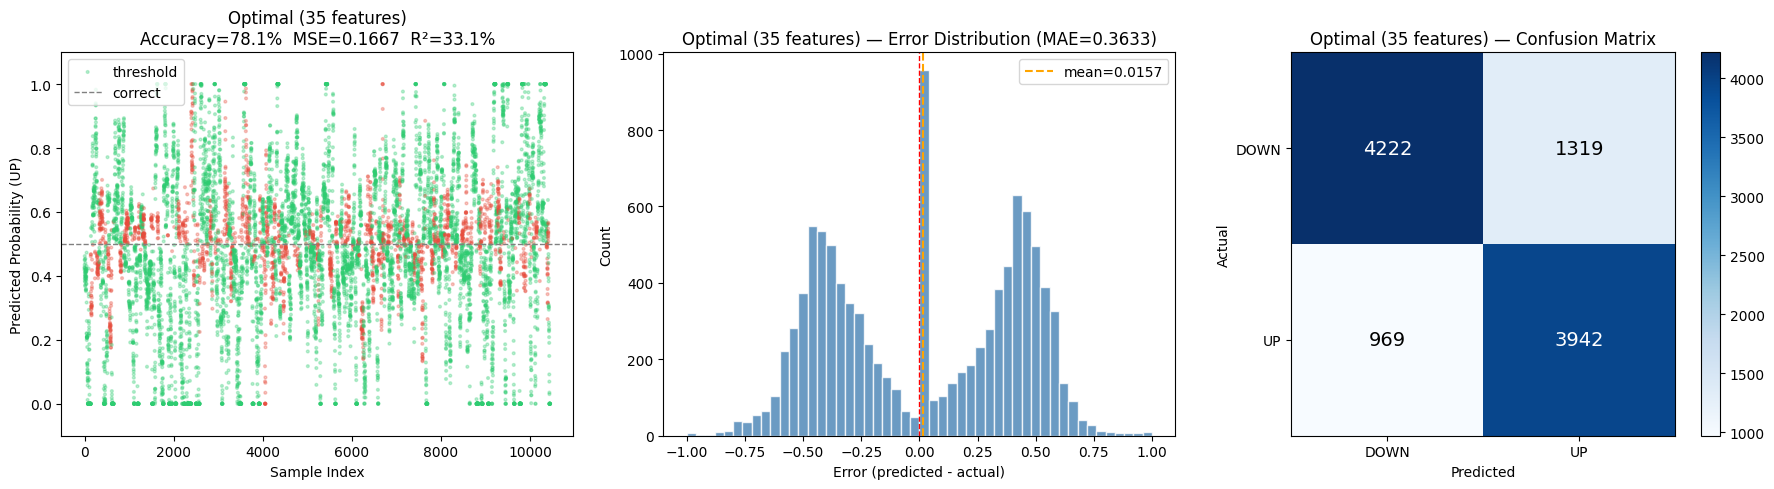

In [10]:
# Train final model with optimal feature set
X_train_sel = X_train[:, optimal_indices]
X_test_sel = X_test[:, optimal_indices]

model_opt = LinearRegression()
model_opt.fit(X_train_sel, y_train)

y_prob_opt = np.clip(model_opt.predict(X_test_sel), 0, 1)
y_pred_opt = (y_prob_opt >= 0.5).astype(int)

# Evaluate
ev_opt = Evaluator(y_test, y_pred_opt, y_prob_opt, title=f"Optimal ({N_best} features)")
ev_opt.full_report()

### Side-by-side comparison

In [11]:
print(f"{'Model':<30} {'Accuracy':>10} {'MSE':>10} {'R²':>10} {'F1':>10}")
print("-" * 75)
for ev in [ev_all, ev_opt]:
    print(f"{ev.title:<30} {ev.accuracy * 100:>9.2f}% {ev.mse:>10.4f} {ev.r2 * 100:>9.1f}% {ev.f1 * 100:>9.1f}%")
print(f"\nFeatures dropped: {N_TOTAL - N_best} out of {N_TOTAL} (overfitting indicators removed)")

Model                            Accuracy        MSE         R²         F1
---------------------------------------------------------------------------
All Features (47)                  76.33%     0.1610      35.4%      74.7%
Optimal (35 features)              78.11%     0.1667      33.1%      77.5%

Features dropped: 25 out of 60 (overfitting indicators removed)


### Feature coefficients

**How to read the coefficient chart:**
- Each bar = one feature in the optimal set
- **Positive (right)** = higher values of this feature predict UP
- **Negative (left)** = higher values predict DOWN
- **Magnitude** = how much influence the feature has (after normalization, so they're comparable)
- Example: if `btc_move_from_open` has a large positive coefficient, it means "when BTC has moved up from the open, predict UP" — which makes intuitive sense

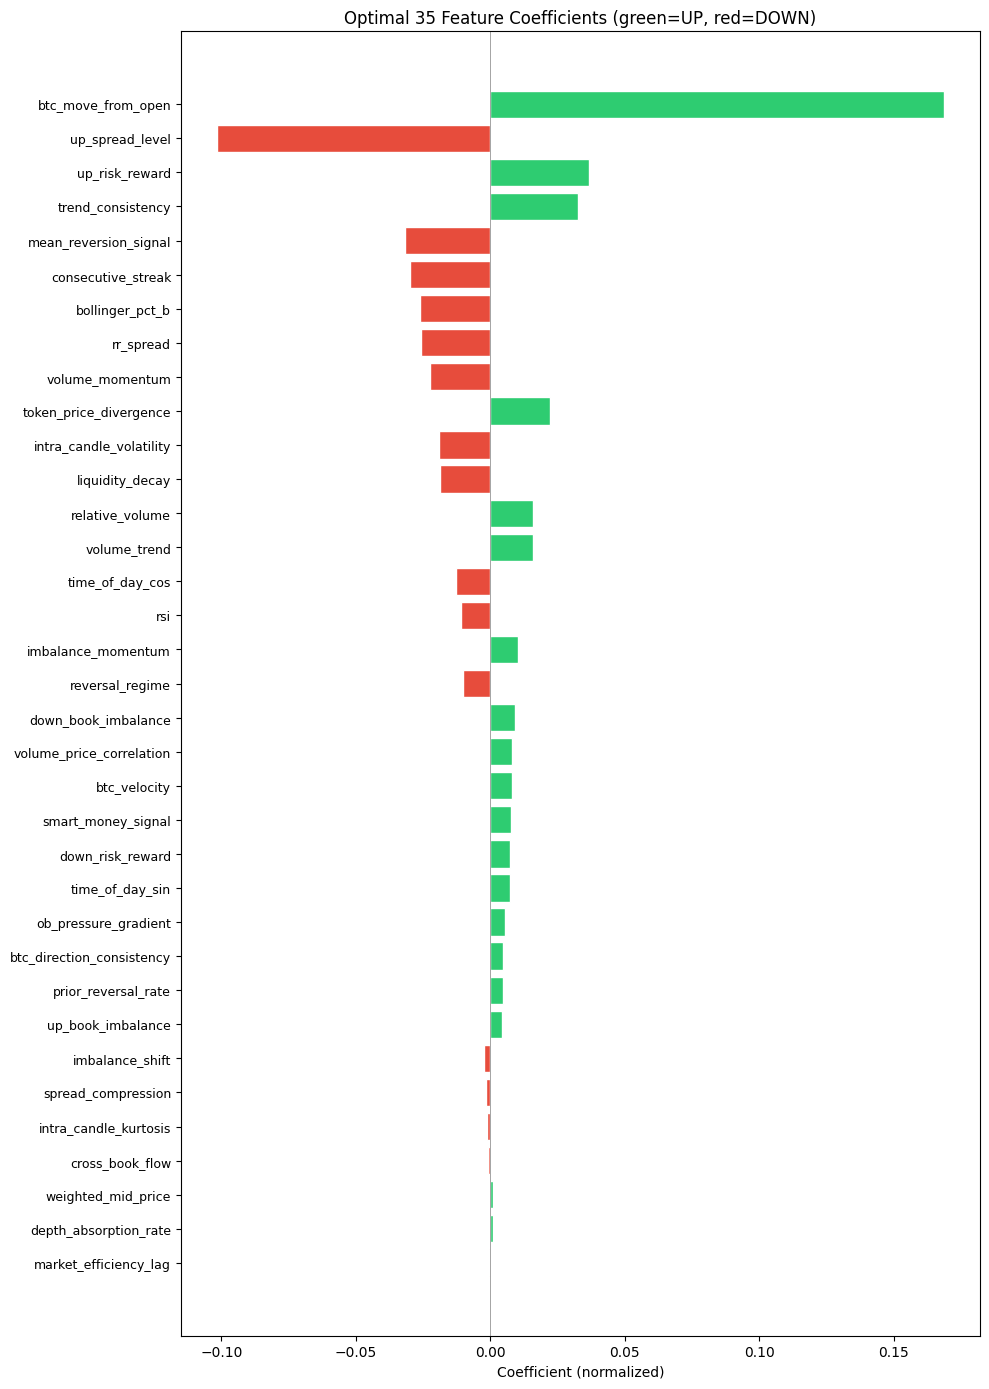

In [12]:
# Feature coefficients
coeffs = model_opt.coef_
sorted_idx = np.argsort(np.abs(coeffs))[::-1]

fig, ax = plt.subplots(figsize=(10, max(4, N_best * 0.4)))
sorted_names = [optimal_names[i] for i in sorted_idx]
sorted_coeffs = coeffs[sorted_idx]
colors = ["#2ecc71" if c > 0 else "#e74c3c" for c in sorted_coeffs]
ax.barh(range(len(sorted_names)), sorted_coeffs, color=colors, edgecolor="white")
ax.set_yticks(range(len(sorted_names)))
ax.set_yticklabels(sorted_names, fontsize=9)
ax.set_xlabel("Coefficient (normalized)")
ax.set_title(f"Optimal {N_best} Feature Coefficients (green=UP, red=DOWN)")
ax.axvline(0, color="gray", linestyle="-", linewidth=0.5)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 8. Summary

**What:** Final summary of the top 10 features and key takeaways.

In [13]:
print("=" * 60)
print(f"OPTIMAL FEATURES ({N_best} selected, {N_TOTAL - N_best} dropped)")
print("=" * 60)
for i in range(N_best):
    _step, acc, name = history[i]
    coeff = model_opt.coef_[i]
    direction = "→ UP" if coeff > 0 else "→ DOWN"
    print(f"  {i + 1:>2}. {name:<30} acc={acc * 100:.2f}%  coeff={coeff:+.4f} {direction}")

print(f"\nBaseline (all {N_TOTAL}):  accuracy={ev_all.accuracy * 100:.2f}%  MSE={ev_all.mse:.4f}")
print(f"Optimal ({N_best} feat):   accuracy={ev_opt.accuracy * 100:.2f}%  MSE={ev_opt.mse:.4f}")
print("Random baseline:     accuracy=50.00%")

dropped = selected_names[N_best:]
print(f"\nDropped features ({len(dropped)} — cause overfitting):")
for i, name in enumerate(dropped):
    print(f"  {N_best + i + 1:>2}. {name}")

OPTIMAL FEATURES (35 selected, 25 dropped)
   1. btc_move_from_open             acc=75.49%  coeff=+0.1685 → UP
   2. up_spread_level                acc=76.31%  coeff=-0.1016 → DOWN
   3. ob_pressure_gradient           acc=76.44%  coeff=+0.0055 → UP
   4. rr_spread                      acc=76.52%  coeff=-0.0260 → DOWN
   5. volume_momentum                acc=76.56%  coeff=-0.0226 → DOWN
   6. relative_volume                acc=76.88%  coeff=+0.0160 → UP
   7. btc_direction_consistency      acc=76.91%  coeff=+0.0048 → UP
   8. down_risk_reward               acc=76.98%  coeff=+0.0075 → UP
   9. depth_absorption_rate          acc=76.98%  coeff=+0.0009 → UP
  10. weighted_mid_price             acc=76.98%  coeff=+0.0010 → UP
  11. spread_compression             acc=76.97%  coeff=-0.0015 → DOWN
  12. imbalance_momentum             acc=76.96%  coeff=+0.0104 → UP
  13. imbalance_shift                acc=76.96%  coeff=-0.0023 → DOWN
  14. mean_reversion_signal          acc=76.92%  coeff=-0.0317 

## 9. LogisticRegression Comparison

**What:** Train a LogisticRegression model — the proper classifier for binary outcomes — and compare it against LinearRegression.

**Why:** LinearRegression predicts a continuous value and can output values outside [0, 1] (which we clip). LogisticRegression is mathematically designed for binary classification:
- It applies a **sigmoid function** to the linear combination, so outputs are naturally bounded in [0, 1]
- It optimizes **log-loss** (cross-entropy), not squared error — which is the correct loss for probability estimation
- It produces **calibrated probabilities** by design, meaning if the model says 0.7, it should be right ~70% of the time

**What to expect:**
- If LogisticRegression accuracy is similar to LinearRegression → the problem is roughly linear, both models find the same boundary
- If significantly better → the sigmoid helps, and probability calibration matters
- If significantly worse → unlikely, but would suggest the data has unusual properties

We train three variants:
1. **All features** — direct comparison with LinearRegression baseline
2. **Optimal N features** — same features from forward selection
3. **Own optimal N** — forward selection re-done with LogisticRegression (different model may prefer different features and a different N)

=== Logistic — All Features (47) ===
  Regression:      MSE=0.1583  R²=36.4%  MAE=0.3053
  Classification:  Accuracy=76.2%  Precision=75.5%  Recall=72.9%  F1=74.2%
  Samples:         10452 (UP=4911, DOWN=5541)


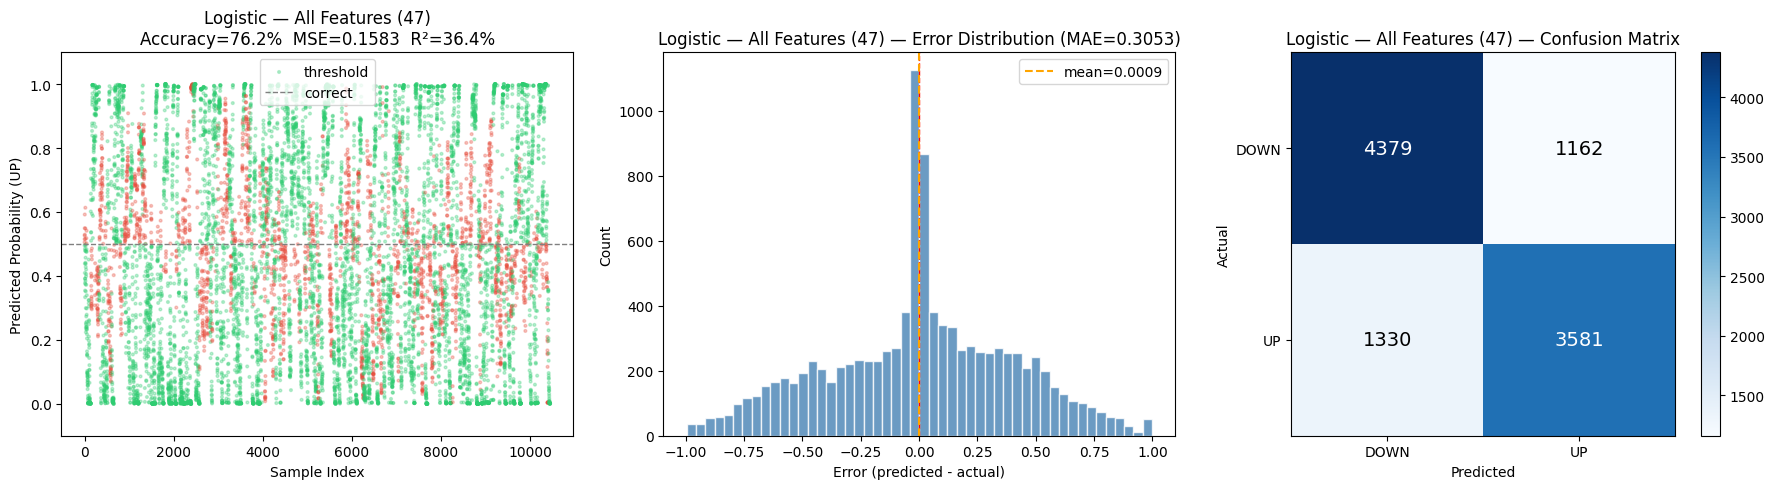

In [14]:
from sklearn.linear_model import LogisticRegression

# --- 9a. LogisticRegression with ALL features ---
log_all = LogisticRegression(max_iter=1000, random_state=42)
log_all.fit(X_train, y_train)

y_prob_log_all = log_all.predict_proba(X_test)[:, 1]  # probability of class 1 (UP)
y_pred_log_all = log_all.predict(X_test)

ev_log_all = Evaluator(y_test, y_pred_log_all, y_prob_log_all, title="Logistic — All Features (47)")
ev_log_all.full_report()

=== Logistic — Optimal 35 (LR-selected) ===
  Regression:      MSE=0.1503  R²=39.7%  MAE=0.3033
  Classification:  Accuracy=77.4%  Precision=76.1%  Recall=75.6%  F1=75.8%
  Samples:         10452 (UP=4911, DOWN=5541)


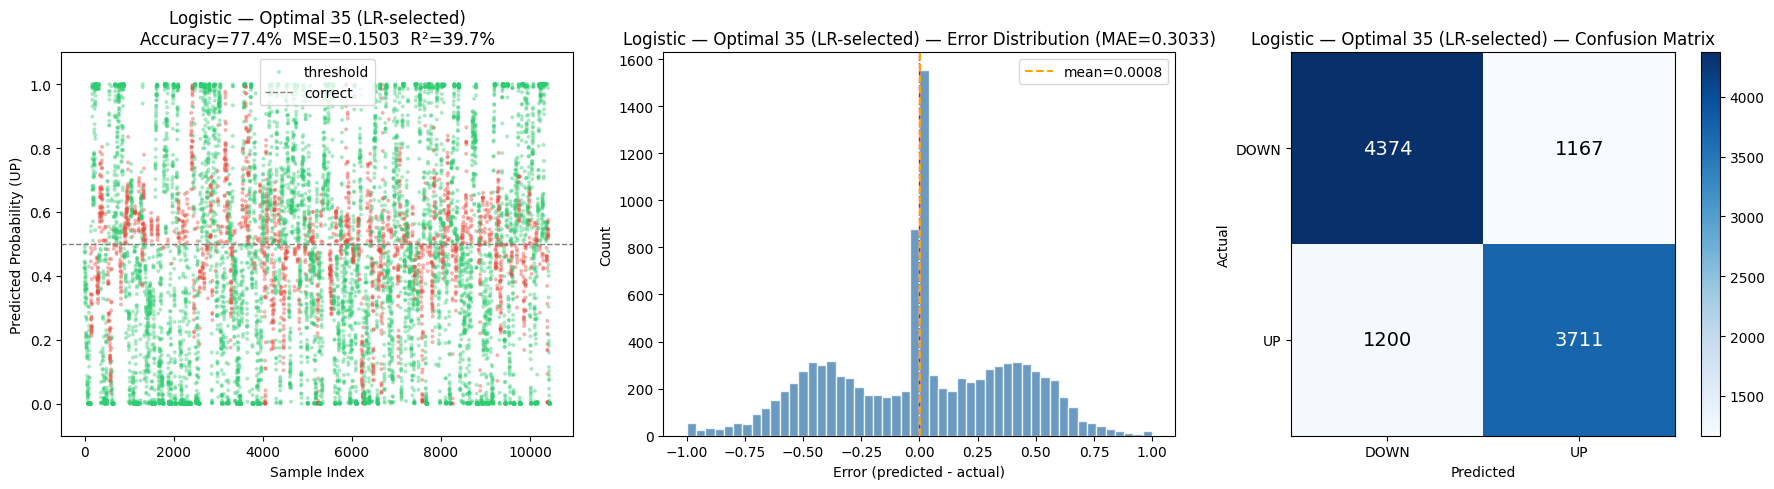

In [15]:
# --- 9b. LogisticRegression with optimal features (from LinearRegression selection) ---
log_opt = LogisticRegression(max_iter=1000, random_state=42)
log_opt.fit(X_train_sel, y_train)

y_prob_log_opt = log_opt.predict_proba(X_test_sel)[:, 1]
y_pred_log_opt = log_opt.predict(X_test_sel)

ev_log_opt = Evaluator(y_test, y_pred_log_opt, y_prob_log_opt, title=f"Logistic — Optimal {N_best} (LR-selected)")
ev_log_opt.full_report()

### 9c. Forward selection re-done with LogisticRegression

**What:** Re-run forward selection through ALL features using LogisticRegression, auto-detect its own optimal N.

**Why:** LogisticRegression optimizes log-loss instead of squared error — it may prefer different features and find a different optimal count. Comparing the two optimal sets reveals whether the model type matters for feature selection.

In [16]:
log_selected_indices = []
log_selected_names = []
log_remaining = list(range(N_TOTAL))
log_history = []

for step in tqdm(range(N_TOTAL), desc="Logistic forward selection"):
    best_acc = -1
    best_idx = -1

    for candidate in log_remaining:
        trial = log_selected_indices + [candidate]
        m = LogisticRegression(max_iter=1000, random_state=42)
        m.fit(X_train[:, trial], y_train)
        pred = m.predict(X_test[:, trial])
        acc = float(np.mean(pred == y_test))

        if acc > best_acc:
            best_acc = acc
            best_idx = candidate

    log_selected_indices.append(best_idx)
    log_selected_names.append(feature_cols[best_idx])
    log_remaining.remove(best_idx)
    log_history.append((step + 1, best_acc, feature_cols[best_idx]))

    if (step + 1) % 10 == 0 or step < 5:
        print(f"  Step {step + 1:>2}: +{feature_cols[best_idx]:<30} → accuracy={best_acc * 100:.2f}%")

# Find Logistic optimal N
log_accs_arr = [h[1] for h in log_history]
log_N_best = int(np.argmax(log_accs_arr)) + 1
log_best_acc_val = max(log_accs_arr)

print(f"\nLogistic optimal N = {log_N_best} features (accuracy = {log_best_acc_val * 100:.2f}%)")
print(f"Logistic optimal features: {log_selected_names[:log_N_best]}")

Logistic forward selection:   2%|▏         | 1/60 [00:00<00:14,  4.10it/s]

  Step  1: +btc_move_from_open             → accuracy=75.33%


Logistic forward selection:   3%|▎         | 2/60 [00:00<00:14,  3.91it/s]

  Step  2: +up_spread_level                → accuracy=76.44%


Logistic forward selection:   5%|▌         | 3/60 [00:00<00:15,  3.67it/s]

...

  Step 40: +hurst_exponent                 → accuracy=78.21%


Logistic forward selection:  83%|████████▎ | 50/60 [00:32<00:07,  1.26it/s]

  Step 50: +ma_crossover                   → accuracy=77.03%


Logistic forward selection: 100%|██████████| 60/60 [00:38<00:00,  1.54it/s]

  Step 60: +return_autocorrelation         → accuracy=76.16%

Logistic optimal N = 31 features (accuracy = 78.24%)
Logistic optimal features: ['btc_move_from_open', 'up_spread_level', 'token_price_divergence', 'btc_direction_consistency', 'reversal_regime', 'price_path_entropy', 'ob_pressure_gradient', 'volume_price_correlation', 'prior_return', 'prior_reversal_rate', 'liquidity_decay', 'cross_book_flow', 'depth_absorption_rate', 'btc_token_correlation', 'volume_momentum', 'rr_spread', 'relative_volume', 'btc_velocity', 'trend_consistency', 'bollinger_pct_b', 'consecutive_streak', 'time_of_day_cos', 'stochastic_k', 'smart_money_signal', 'current_elapsed', 'intra_candle_kurtosis', 'candle_momentum', 'time_of_day_sin', 'rsi', 'weighted_mid_price', 'up_book_imbalance']


=== Logistic — Optimal 31 (own sel.) ===
  Regression:      MSE=0.1504  R²=39.6%  MAE=0.3017
  Classification:  Accuracy=78.2%  Precision=76.7%  Recall=77.0%  F1=76.9%
  Samples:         10452 (UP=4911, DOWN=5541)


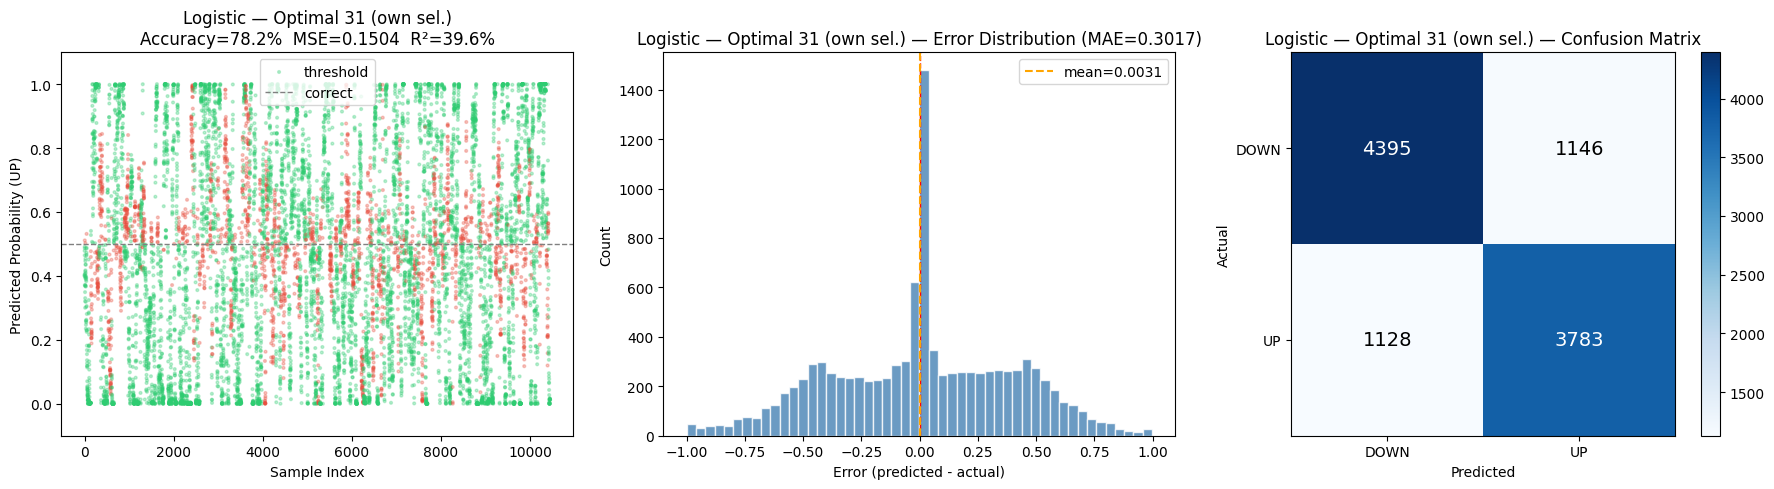

In [17]:
# Train final Logistic model with its own optimal features
log_optimal_indices = log_selected_indices[:log_N_best]
log_optimal_names = log_selected_names[:log_N_best]

X_train_log_sel = X_train[:, log_optimal_indices]
X_test_log_sel = X_test[:, log_optimal_indices]

log_own = LogisticRegression(max_iter=1000, random_state=42)
log_own.fit(X_train_log_sel, y_train)

y_prob_log_own = log_own.predict_proba(X_test_log_sel)[:, 1]
y_pred_log_own = log_own.predict(X_test_log_sel)

ev_log_own = Evaluator(y_test, y_pred_log_own, y_prob_log_own, title=f"Logistic — Optimal {log_N_best} (own sel.)")
ev_log_own.full_report()

### Final comparison — all models

**How to read:** All models on the same test set, same seed, same preprocessing. The table shows which approach wins on each metric. Look for:
- Does LogisticRegression beat LinearRegression? (Expected: slightly better MSE/R² due to proper calibration)
- Does the Logistic forward selection pick different features? (If yes, it found interactions that LinearRegression missed)
- Do fewer features match or beat all features? (If yes, most features are noise)

In [18]:
all_evaluators = [ev_all, ev_opt, ev_log_all, ev_log_opt, ev_log_own]

print(f"{'Model':<40} {'Accuracy':>9} {'MSE':>9} {'R²':>9} {'F1':>9}")
print("-" * 80)
for ev in all_evaluators:
    print(f"{ev.title:<40} {ev.accuracy * 100:>8.2f}% {ev.mse:>9.4f} {ev.r2 * 100:>8.1f}% {ev.f1 * 100:>8.1f}%")
print(f"{'Random baseline':<40} {'50.00%':>9}")

# Which features did Logistic select vs Linear?
lr_set = set(optimal_names)
log_set = set(log_optimal_names)
shared = lr_set & log_set
only_linear = lr_set - log_set
only_logistic = log_set - lr_set
print(f"\nLinear optimal: {N_best} features  |  Logistic optimal: {log_N_best} features")
print(f"  Shared ({len(shared)}):         {sorted(shared)}")
if only_linear:
    print(f"  Only in Linear ({len(only_linear)}):  {sorted(only_linear)}")
if only_logistic:
    print(f"  Only in Logistic ({len(only_logistic)}): {sorted(only_logistic)}")

Model                                     Accuracy       MSE        R²        F1
--------------------------------------------------------------------------------
All Features (47)                           76.33%    0.1610     35.4%     74.7%
Optimal (35 features)                       78.11%    0.1667     33.1%     77.5%
Logistic — All Features (47)                76.16%    0.1583     36.4%     74.2%
Logistic — Optimal 35 (LR-selected)         77.35%    0.1503     39.7%     75.8%
Logistic — Optimal 31 (own sel.)            78.24%    0.1504     39.6%     76.9%
Random baseline                             50.00%

Linear optimal: 35 features  |  Logistic optimal: 31 features
  Shared (25):         ['bollinger_pct_b', 'btc_direction_consistency', 'btc_move_from_open', 'btc_velocity', 'consecutive_streak', 'cross_book_flow', 'depth_absorption_rate', 'intra_candle_kurtosis', 'liquidity_decay', 'ob_pressure_gradient', 'prior_reversal_rate', 'relative_volume', 'reversal_regime', 'rr_spread', '

## 11. Export optimal LR features

Save the LogisticRegression optimal feature set to `data/optimal_features_lr.json` so all downstream notebooks load from a single source of truth.

In [ ]:
import json as _json
from datetime import UTC, datetime

config = {
    "model": "logistic_regression",
    "features": sorted(log_optimal_names),
    "n_features": log_N_best,
    "accuracy": round(log_best_acc_val, 4),
    "selection_method": "forward_selection",
    "source": "data/latest_features.jsonl",
    "created_at": datetime.now(UTC).isoformat(),
}

out_path = Path("../data/optimal_features_lr.json")
with open(out_path, "w") as f:
    _json.dump(config, f, indent=2)

print(f"Saved {config['n_features']} LR features to {out_path}")
print(f"Accuracy: {config['accuracy'] * 100:.2f}%")
print(f"Features: {config['features']}")

## 12. Conclusion

Results above are based on `data/latest_features.jsonl` (collection.db with 60 indicators including volume).
Time-based 80/20 split. No candle overlap.

The optimal LR feature set has been saved to `data/optimal_features_lr.json`.
All downstream notebooks load from this file — re-run this notebook to update the feature set.